# Adult (FairDPGANs) 

Author: Ilse Harmers \
Last modified: February 17, 2026

In [1]:
# Importing libraries.
import numpy as np
import pandas as pd
from snsynth import Synthesizer
import snsynth.transform as tf
import utils
import warnings
warnings.filterwarnings("ignore", message = r"Using", category = FutureWarning)
warnings.filterwarnings("ignore", message = r"invalid", category = RuntimeWarning)

In [2]:
# Importing train set.
adult_train = pd.read_csv("./train-test-datasets/adult/adult_train.csv")

# Preprocessing the dataset for the Fair DP-GANs; the dataset Fair DP-GANs are expecting the first two columns in the original dataset to be the 
# sensitive and target attributes. 
cols = adult_train.columns.to_list()
cols.remove("sex")
cols.remove("income")
adult_train = adult_train[["sex", "income"] + cols]

print(adult_train.columns.to_list())
adult_train.describe()

['sex', 'income', 'age', 'workclass', 'education-num', 'marital-status', 'occupation', 'relationship', 'race', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country']


,age,education-num,capital-gain,capital-loss,hours-per-week
count,36177.000000,36177.000000,36177.000000,36177.000000,36177.000000
mean,38.558283,10.117091,1089.335766,87.182962,40.952318
std,13.232872,2.554611,7519.871123,401.695413,11.988401
min,17.000000,1.000000,0.000000,0.000000,1.000000
25%,28.000000,9.000000,0.000000,0.000000,40.000000
50%,37.000000,10.000000,0.000000,0.000000,40.000000
75%,47.000000,13.000000,0.000000,0.000000,45.000000
max,90.000000,16.000000,99999.000000,4356.000000,99.000000


In [3]:
# Setting up preprocessor table transformer.

tt = tf.TableTransformer([
    tf.ChainTransformer([tf.LabelTransformer(), tf.OneHotEncoder()]), # sex
    tf.ChainTransformer([tf.LabelTransformer(), tf.OneHotEncoder()]), # income
    tf.MinMaxTransformer(lower = adult_train["age"].min(), upper = adult_train["age"].max(), 
                         negative = False), # age; scaling to range (0, 1)
    tf.ChainTransformer([tf.LabelTransformer(), tf.OneHotEncoder()]), # workclass
    tf.ChainTransformer([tf.LabelTransformer(), tf.OneHotEncoder()]), # education-num
    tf.ChainTransformer([tf.LabelTransformer(), tf.OneHotEncoder()]), # marital-status
    tf.ChainTransformer([tf.LabelTransformer(), tf.OneHotEncoder()]), # occupation
    tf.ChainTransformer([tf.LabelTransformer(), tf.OneHotEncoder()]), # relationship
    tf.ChainTransformer([tf.LabelTransformer(), tf.OneHotEncoder()]), # race
    tf.ChainTransformer([
        tf.LogModulusTransformer(),
        tf.MinMaxTransformer(lower = 0, upper = np.log(adult_train["capital-gain"].max() + 1),
                             negative = False) # capital-gain; scaling to range (0, 1)
    ]),
    tf.ChainTransformer([
        tf.LogModulusTransformer(),
        tf.MinMaxTransformer(lower = 0, upper = np.log(4400.0 + 1),   # 1 id with 4356.0; rounded up w.r.t. privacy
                             negative = False) # capital-loss; scaling to range (0, 1)
    ]),
    tf.MinMaxTransformer(lower = adult_train["hours-per-week"].min(), 
                         upper = adult_train["hours-per-week"].max(), 
                         negative = False), # hours-per-week; scaling to range (0, 1)
    tf.ChainTransformer([tf.LabelTransformer(), tf.OneHotEncoder()]), # native-country
])

In [4]:
# Defining delta as the inverse of the size of the dataset: if a dataset has 4 * 10^4 rows, then delta = 10^(-5). 
delta = 10**np.floor(np.log10(1/adult_train.shape[0]))
print(delta)

# Defining beta1 in Adam optimizer.
beta1 = 0.9 

# Defining epsilon value.
epsi = 1

# Defining Fair DP-GAN: [dem, dis, dem-dis, clf_dem, clf_dis, clf_eqopp, clf_all].
fair_loss = "dem"

1e-05


Run 1
{0: ' Female', 1: ' Male'} {0: ' <=50K', 1: ' >50K'}
data.shape: (36177, 104)
cuda:0


C:\Users\ilseh\AppData\Roaming\Python\Python39\site-packages\opacus\privacy_engine.py:638: UserWarning: The sample rate will be defined from ``batch_size`` and ``sample_size``.The returned privacy budget will be incorrect.
  warnings.warn(
C:\Users\ilseh\AppData\Roaming\Python\Python39\site-packages\opacus\privacy_engine.py:229: UserWarning: Secure RNG turned off. This is perfectly fine for experimentation as it allows for much faster training performance, but remember to turn it on and retrain one last time before production with ``secure_rng`` turned on.
  warnings.warn(


Delta:  1e-05
Sample 1 [dem., dis.]:  [0.2526941865627912, -0.7446944644880528]
Sample 2 [dem., dis.]:  [0.2570725438176644, -0.7436405283999565]
Sample 3 [dem., dis.]:  [0.25637297734849823, -0.7410116320088379]


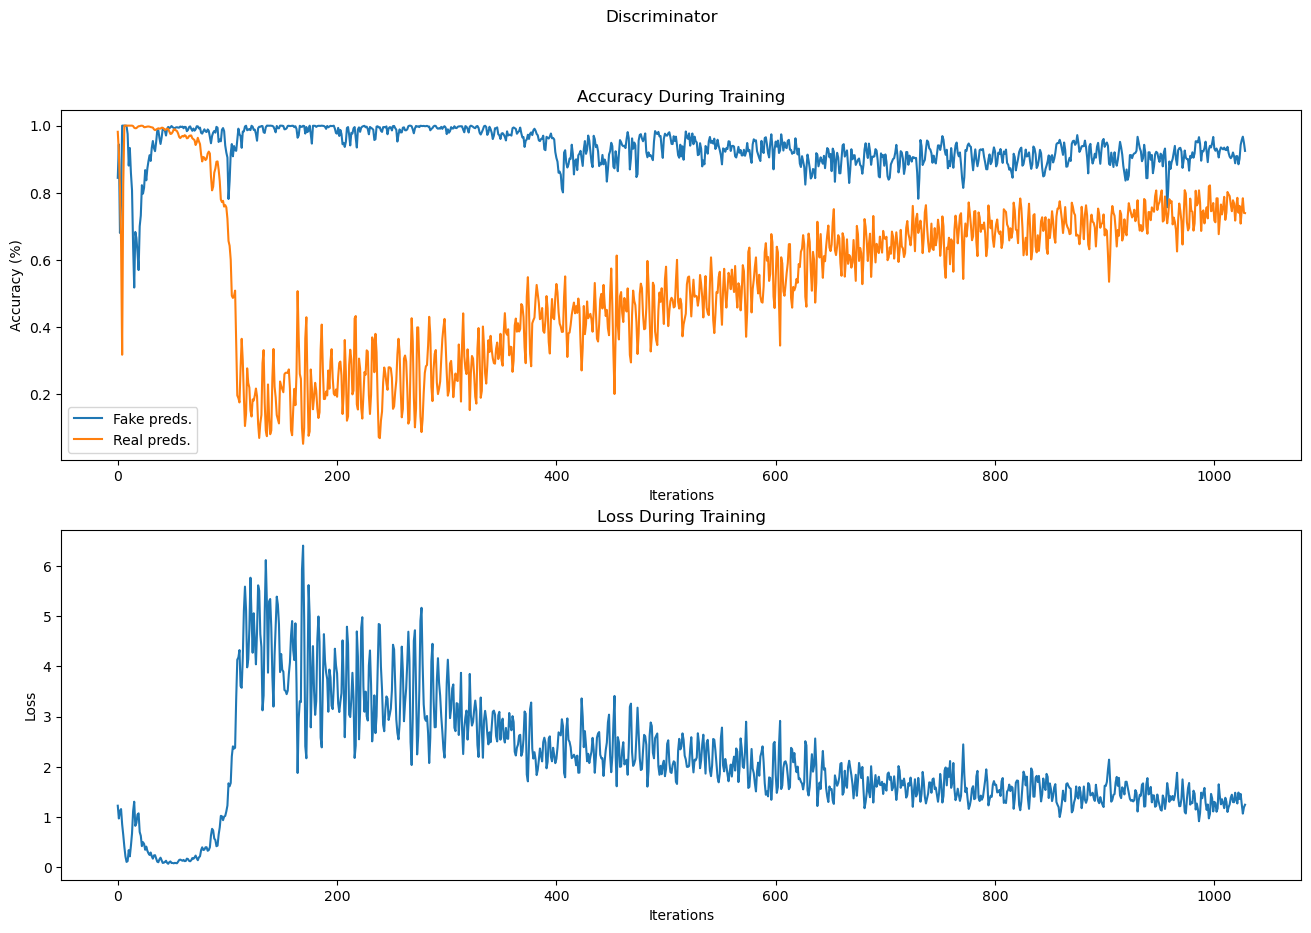

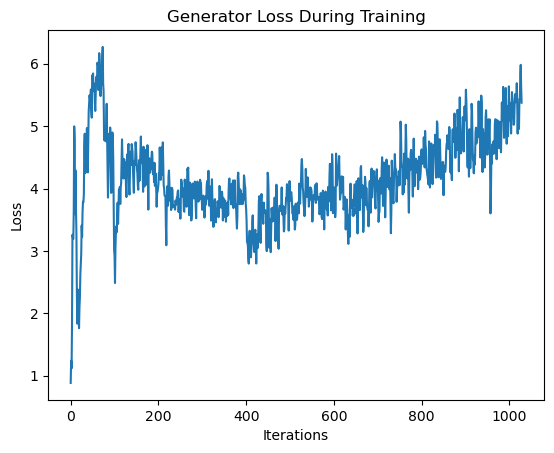

In [5]:
r = 1
while r < 6:
    
    print(f"Run {r}")

    # Synthesizing the dataset with one of the Fair DP-GANs.
    synth = Synthesizer.create('fairdpgan', s = "sex", s_unpriv = " Female", s_priv = " Male", y = "income", y_des = " >50K", fair_loss = fair_loss,
                               epsilon = epsi, delta = delta, beta1 = beta1, plot_losses = True, batch_size = 512, dataset = "Adult", epochs = 10000,
                               file_path = f"synthetic-datasets_FairDP-GAN({fair_loss})_B=512/adult/epsi_{epsi}/run{r}/",
                               #sanity_check = True
                              )
    synth.fit(adult_train, transformer = tt, preprocessor_eps = 0.0)

    try:
        # Generating the first synthetic dataset.
        sample1 = synth.sample(adult_train.shape[0])
        # Encoding the sensitive and target attributes for the fairness analysis.
        sample1_encoded = utils.one_hot_encode(sample1[["sex", "income"]], order = [[" <=50K", " >50K"], [" Female", " Male"]])
        dem1 = utils.demographic_parity(df = sample1_encoded, s = "sex", y = "income")
        dis1 = utils.disparate_impact(df = sample1_encoded, s = "sex", y = "income")
        print("Sample 1 [dem., dis.]: ",  [dem1, dis1])
        
        # Generating the second synthetic dataset.
        sample2 = synth.sample(adult_train.shape[0])
        # Encoding the sensitive and target attributes for the fairness analysis.
        sample2_encoded = utils.one_hot_encode(sample2[["sex", "income"]], order = [[" <=50K", " >50K"], [" Female", " Male"]])
        dem2 = utils.demographic_parity(df = sample2_encoded, s = "sex", y = "income")
        dis2 = utils.disparate_impact(df = sample2_encoded, s = "sex", y = "income")
        print("Sample 2 [dem., dis.]: ",  [dem2, dis2])

        # Generating the third synthetic dataset.
        sample3 = synth.sample(adult_train.shape[0])
        # Encoding the sensitive and target attributes for the fairness analysis.
        sample3_encoded = utils.one_hot_encode(sample3[["sex", "income"]], order = [[" <=50K", " >50K"], [" Female", " Male"]])
        dem3 = utils.demographic_parity(df = sample3_encoded, s = "sex", y = "income")
        dis3 = utils.disparate_impact(df = sample3_encoded, s = "sex", y = "income")
        print("Sample 3 [dem., dis.]: ",  [dem3, dis3])

        # Saving the synthetic datasets.
        sample1.to_csv(f"./synthetic-datasets_FairDP-GAN({fair_loss})_B=512/adult/epsi_{epsi}/run{r}/sample1.csv", index = False)
        sample2.to_csv(f"./synthetic-datasets_FairDP-GAN({fair_loss})_B=512/adult/epsi_{epsi}/run{r}/sample2.csv", index = False)
        sample3.to_csv(f"./synthetic-datasets_FairDP-GAN({fair_loss})_B=512/adult/epsi_{epsi}/run{r}/sample3.csv", index = False)
        
        r += 1
    except ZeroDivisionError:
        r += 0